# Lab 12 — Ablations and Final Report

**Goal:** explain what we learned from the whole course with a small number of targeted ablations.

This is not another optimization lab.

We already trained:

```text
Base Qwen3-0.6B
        ↓
Full SFT
        ↓
LoRA
        ↓
Symbolic policy distillation
        ↓
GRPO
```

Some internal metrics improved dramatically while actual Wordle gameplay barely moved.

Lab 12 asks **why**.

We will run four focused analyses:

1. **Unified benchmark ablation** — evaluate every checkpoint under the same 19-game harness.
2. **Prompt-distribution ablation** — does full SFT behave better under the prompt style it was actually trained on?
3. **Distillation scaffold ablation** — compare candidate-constrained ranking with free generation on the same states.
4. **RL surrogate ablation** — did GRPO at least improve held-out one-step shaped reward even though end-to-end gameplay did not?

Then we produce the final report.

No large training run is required.

## 12.1 Course hypotheses

By the end of Lab 11 we have four plausible explanations for the failures:

### H1 — Prompt / state distribution mismatch

The SFT model was trained mostly on curriculum prompts such as:

```text
Task: NEXT_GUESS
History:
...
```

but deployed under a different gameplay prompt.

### H2 — The model can rank actions better than it can generate them

Lab 09 achieved **92.7% held-out teacher top-1 agreement** when Qwen was explicitly asked to score a known candidate set, yet free generation collapsed into garbage.

### H3 — One-step RL optimized a surrogate without learning a multi-turn policy

GRPO had healthy reward variance, but the final policy still repeated `CRANE`.

### H4 — The bottleneck is representation/capability, not simply optimizer choice

Full SFT, LoRA, distillation, and RL changed the optimization method, but none taught robust autonomous history-conditioned Wordle play.

The ablations below test these hypotheses directly.

## 12.2 Imports and environment

In [1]:
from __future__ import annotations

from pathlib import Path
import gc
import json
import random
import re
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer

from tiny_wordle.game import Turn, filter_candidates, score_string
from tiny_wordle.expert import EntropyExpert
from tiny_wordle.rewards import reward_breakdown
from tiny_wordle.benchmark import (
    DEFAULT_EVAL_ANSWERS,
    DEFAULT_SYSTEM_RULES,
    run_benchmark,
)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device(
    "mps" if torch.backends.mps.is_available() else "cpu"
)

print("device:", device)
print("PyTorch:", torch.__version__)

device: mps
PyTorch: 2.13.0


## 12.3 Checkpoint registry

We want one place that records every model produced by the course.

If a checkpoint is missing, the notebook will skip it rather than fail.

In [2]:
CHECKPOINTS = {
    "base": "Qwen/Qwen3-0.6B",
    "full_sft": "../checkpoints/qwen3-0.6b-wordle-full-sft",
    "lora": "../checkpoints/qwen3-0.6b-wordle-lora-merged",
    "distilled": "../checkpoints/qwen3-0.6b-symbolic-policy-distilled",
    "grpo": "../checkpoints/qwen3-0.6b-wordle-grpo-merged",
}

def checkpoint_available(model_id: str) -> bool:
    if model_id.startswith("Qwen/"):
        return True
    return Path(model_id).exists()

available = {
    name: checkpoint_available(path)
    for name, path in CHECKPOINTS.items()
}

pd.Series(available, name="available")

base         True
full_sft     True
lora         True
distilled    True
grpo         True
Name: available, dtype: bool

# Ablation 1 — Unified 19-game benchmark

Previous labs sometimes used slightly different answer counts while the harness evolved.

For the final report, rerun every available checkpoint through the **same reusable 19-game benchmark**.

This gives us the cleanest end-to-end comparison in the course.

In [3]:
benchmark_rows = []

for name, model_id in CHECKPOINTS.items():
    if not available[name]:
        print("SKIP", name, model_id)
        continue

    print()
    print("#" * 72)
    print(name.upper())
    print("#" * 72)

    summary, games_df, results = run_benchmark(
        model_id,
        answers=DEFAULT_EVAL_ANSWERS,
        verbose_games=False,
        print_failures=False,
    )

    benchmark_rows.append({
        "model": name,
        "solve_rate": summary["solve_rate"],
        "valid_output_rate": summary["valid_output_rate"],
        "invalid_output_rate": summary["invalid_output_rate"],
        "repeat_guesses": summary["repeat_guesses"],
        "history_consistency_rate": summary["history_consistency_rate"],
        "mean_turns_on_wins": summary["mean_turns_on_wins"],
        "total_eval_seconds": summary["total_eval_seconds"],
    })

    gc.collect()
    if device.type == "mps":
        torch.mps.empty_cache()

benchmark_df = pd.DataFrame(benchmark_rows)

benchmark_df


########################################################################
BASE
########################################################################


Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

model: Qwen/Qwen3-0.6B
device: mps
dtype: torch.float32
games: 19


BENCHMARK SUMMARY
games:                19
solved:               1
solve rate:           5.3%
model calls:          109
valid output rate:    100.0%
invalid output rate:  0.0%
repeat guesses:       72
history consistency:  0.0% (0/90)
mean turns on wins:   1.0
total eval time:      8.7s

########################################################################
FULL_SFT
########################################################################


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

model: ../checkpoints/qwen3-0.6b-wordle-full-sft
device: mps
dtype: torch.float32
games: 19


BENCHMARK SUMMARY
games:                19
solved:               1
solve rate:           5.3%
model calls:          109
valid output rate:    100.0%
invalid output rate:  0.0%
repeat guesses:       75
history consistency:  0.0% (0/90)
mean turns on wins:   1.0
total eval time:      7.3s

########################################################################
LORA
########################################################################


...

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

model: ../checkpoints/qwen3-0.6b-symbolic-policy-distilled
device: mps
dtype: torch.float32
games: 19


BENCHMARK SUMMARY
games:                19
solved:               0
solve rate:           0.0%
model calls:          114
valid output rate:    0.0%
invalid output rate:  100.0%
repeat guesses:       0
history consistency:  nan% (0/0)
mean turns on wins:   nan
total eval time:      32.3s

########################################################################
GRPO
########################################################################


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

model: ../checkpoints/qwen3-0.6b-wordle-grpo-merged
device: mps
dtype: torch.float32
games: 19


BENCHMARK SUMMARY
games:                19
solved:               1
solve rate:           5.3%
model calls:          109
valid output rate:    100.0%
invalid output rate:  0.0%
repeat guesses:       86
history consistency:  0.0% (0/90)
mean turns on wins:   1.0
total eval time:      7.1s


,model,solve_rate,valid_output_rate,invalid_output_rate,repeat_guesses,history_consistency_rate,mean_turns_on_wins,total_eval_seconds
0,base,0.052632,1.0,0.0,72,0.0,1.0,8.718208
1,full_sft,0.052632,1.0,0.0,75,0.0,1.0,7.326488
2,lora,0.000000,1.0,0.0,95,0.0,NaN,9.247694
3,distilled,0.000000,0.0,1.0,0,NaN,NaN,32.299481
4,grpo,0.052632,1.0,0.0,86,0.0,1.0,7.100464


### 12.4 Plot the unified benchmark

Do not put solve rate and repetition on one axis. They have unrelated scales.

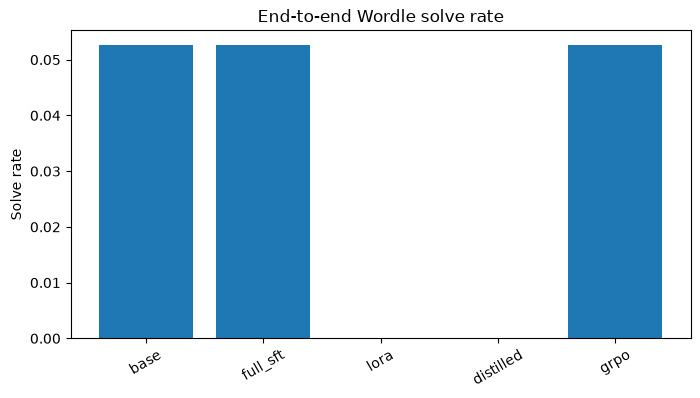

In [4]:
if not benchmark_df.empty:
    plt.figure(figsize=(8, 4))
    plt.bar(
        benchmark_df["model"],
        benchmark_df["solve_rate"],
    )
    plt.ylabel("Solve rate")
    plt.title("End-to-end Wordle solve rate")
    plt.xticks(rotation=30)
    plt.show()

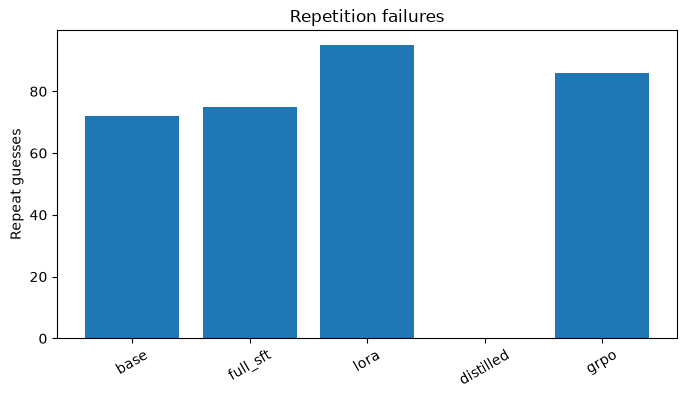

In [5]:
if not benchmark_df.empty:
    plt.figure(figsize=(8, 4))
    plt.bar(
        benchmark_df["model"],
        benchmark_df["repeat_guesses"],
    )
    plt.ylabel("Repeat guesses")
    plt.title("Repetition failures")
    plt.xticks(rotation=30)
    plt.show()

# Ablation 2 — Prompt-distribution mismatch

Lab 07 trained `NEXT_GUESS` examples with one prompt protocol but Lab 04 deployed another.

This ablation holds the **model and Wordle state fixed** and changes only the prompt framing.

For each held-out `NEXT_GUESS` row:

```text
A. original Lab 06 curriculum prompt
B. equivalent Lab 04 gameplay prompt
```

Then measure:

- strict five-letter output rate;
- exact match to the symbolic target;
- history consistency.

If curriculum framing performs substantially better, prompt distribution mismatch mattered.

If both are poor, the failure is deeper than prompt wording.

## 12.5 Load held-out NEXT_GUESS states

In [6]:
GENERATED_DIR = Path("../data/generated")

lab06 = load_dataset(
    "json",
    data_files={
        "validation": str(
            GENERATED_DIR / "wordle-sft-dev.jsonl"
        )
    },
)

next_guess_rows = [
    row
    for row in lab06["validation"]
    if row["task"] == "NEXT_GUESS"
]

print("validation NEXT_GUESS rows:", len(next_guess_rows))

Generating validation split: 0 examples [00:00, ? examples/s]

validation NEXT_GUESS rows: 385


In [7]:
def parse_curriculum_history(prompt: str) -> list[Turn]:
    if "History:\n" not in prompt:
        return []

    text = prompt.split("History:\n", 1)[1]

    for marker in [
        "\n\nCandidate:",
        "\n\nOption A:",
    ]:
        text = text.split(marker, 1)[0]

    history = []

    for line in text.splitlines():
        if "->" not in line:
            continue

        left, right = line.split("->", 1)

        guess = (
            left.replace(" ", "")
            .strip()
            .upper()
        )

        feedback = (
            right.replace(" ", "")
            .strip()
            .upper()
        )

        if (
            len(guess) == 5
            and len(feedback) == 5
        ):
            history.append(
                Turn(
                    guess,
                    feedback,
                )
            )

    return history

def gameplay_prompt_from_history(
    history: list[Turn],
) -> str:
    if not history:
        history_text = (
            "No guesses have been made yet."
        )
    else:
        history_text = "\n".join(
            f"{' '.join(t.guess)} -> "
            f"{' '.join(t.feedback)}"
            for t in history
        )

    return (
        DEFAULT_SYSTEM_RULES
        + "\nGame history:\n"
        + history_text
    )

## 12.6 Generation helper

In [8]:
STRICT_WORD_RE = re.compile(
    r"^[A-Z]{5}$"
)

def load_model_and_tokenizer(
    model_id: str,
):
    tokenizer = AutoTokenizer.from_pretrained(
        model_id
    )

    model = (
        AutoModelForCausalLM
        .from_pretrained(
            model_id,
            dtype=torch.float32,
        )
        .to(device)
    )

    model.eval()

    return tokenizer, model

@torch.no_grad()
def generate_one(
    tokenizer,
    model,
    prompt: str,
    max_new_tokens: int = 16,
) -> str:
    chat_text = tokenizer.apply_chat_template(
        [
            {
                "role": "user",
                "content": prompt,
            }
        ],
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=False,
    )

    batch = tokenizer(
        chat_text,
        return_tensors="pt",
    ).to(device)

    output = model.generate(
        **batch,
        max_new_tokens=max_new_tokens,
        do_sample=False,
    )

    new = output[
        0,
        batch["input_ids"].shape[1]:,
    ]

    return tokenizer.decode(
        new,
        skip_special_tokens=True,
    ).strip()

## 12.7 Run prompt ablation on the full-SFT checkpoint

In [9]:
PROMPT_ABLATION_ROWS = min(
    100,
    len(next_guess_rows),
)

prompt_sample = next_guess_rows[
    :PROMPT_ABLATION_ROWS
]

full_sft_id = CHECKPOINTS["full_sft"]

assert available["full_sft"]

tokenizer, model = (
    load_model_and_tokenizer(
        full_sft_id
    )
)

prompt_records = []

for i, row in enumerate(
    prompt_sample,
    1,
):
    history = parse_curriculum_history(
        row["prompt"]
    )

    curriculum_output = generate_one(
        tokenizer,
        model,
        row["prompt"],
    )

    gameplay_output = generate_one(
        tokenizer,
        model,
        gameplay_prompt_from_history(
            history
        ),
    )

    expected = (
        row["response"]
        .strip()
        .upper()
    )

    for prompt_style, output in [
        ("curriculum", curriculum_output),
        ("gameplay", gameplay_output),
    ]:
        normalized = output.strip().upper()

        strict_valid = bool(
            STRICT_WORD_RE.fullmatch(
                normalized
            )
        )

        consistent = (
            strict_valid
            and all(
                score_string(
                    normalized,
                    old.guess,
                )
                == old.feedback
                for old in history
            )
        )

        prompt_records.append({
            "prompt_style": prompt_style,
            "expected": expected,
            "output": normalized,
            "strict_valid": strict_valid,
            "exact": normalized == expected,
            "history_consistent": consistent,
            "turn": row["turn"],
            "candidate_count": row["candidate_count"],
        })

    if i % 25 == 0:
        print(
            f"{i}/{PROMPT_ABLATION_ROWS}"
        )

prompt_df = pd.DataFrame(
    prompt_records
)

del model
gc.collect()

if device.type == "mps":
    torch.mps.empty_cache()

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

25/100
50/100
75/100
100/100


In [10]:
prompt_summary = (
    prompt_df
    .groupby("prompt_style")
    .agg(
        rows=("exact", "size"),
        strict_valid=("strict_valid", "mean"),
        exact=("exact", "mean"),
        history_consistent=(
            "history_consistent",
            "mean",
        ),
    )
)

prompt_summary

,rows,strict_valid,exact,history_consistent
prompt_style,,,,
curriculum,100,0.97,0.00,0.05
gameplay,100,0.99,0.01,0.04


### Interpret Ablation 2

Three possible outcomes:

**Curriculum ≫ gameplay**

Prompt distribution mismatch materially contributed to failure.

**Both poor**

The model did not learn the state→action mapping even under its training protocol.

**Both good**

The frozen gameplay benchmark is exposing some other mismatch.

Do not retrofit the conclusion. Let the numbers decide.

# Ablation 3 — Distillation scaffold vs free generation

Lab 09's strongest result was:

```text
teacher top-1 agreement: 92.7%
```

But that evaluation handed the student a known candidate set and asked it to **rank** the options.

The gameplay benchmark instead asks the model to freely generate from the full vocabulary.

This ablation measures both behaviors on the **same held-out policy states**.

## 12.8 Rebuild the symbolic expert state pool

In [11]:
ANSWERS = [
    line.strip().upper()
    for line in (
        Path("../data")
        / "wordle-answers-original.txt"
    ).read_text().splitlines()
    if line.strip()
]

PATTERNS = np.load(
    "../data/wordle-patterns-original-2315.npy"
)

expert = EntropyExpert(
    ANSWERS,
    PATTERNS,
)

WORD_TO_INDEX = expert.word_to_index
ALL_INDICES = expert.all_indices

In [12]:
def collect_policy_states_for_answers(
    answers: list[str],
    max_turns: int = 6,
):
    states = []

    for answer in answers:
        candidate_indices = (
            ALL_INDICES.copy()
        )

        history = []

        for turn in range(
            1,
            max_turns + 1,
        ):
            states.append({
                "answer": answer,
                "turn": turn,
                "history": list(history),
                "candidate_indices": (
                    candidate_indices.copy()
                ),
            })

            guess_idx = expert.choose(
                candidate_indices
            )

            guess = ANSWERS[
                guess_idx
            ]

            feedback = score_string(
                answer,
                guess,
            )

            if feedback == "GGGGG":
                break

            history.append(
                Turn(
                    guess,
                    feedback,
                )
            )

            candidate_indices = (
                expert.update(
                    candidate_indices,
                    guess_idx,
                    feedback,
                )
            )

    return states

In [13]:
dev_answers = sorted(
    set(
        lab06["validation"]["answer"]
    )
)

dev_policy_states = (
    collect_policy_states_for_answers(
        dev_answers
    )
)

eligible_dev_policy_states = [
    state
    for state in dev_policy_states
    if (
        state["turn"] > 1
        and 2
        <= len(state["candidate_indices"])
        <= 32
    )
]

DISTILL_ABLATION_STATES = min(
    100,
    len(
        eligible_dev_policy_states
    ),
)

distill_eval_states = (
    random.Random(SEED)
    .sample(
        eligible_dev_policy_states,
        DISTILL_ABLATION_STATES,
    )
)

print(
    "distillation ablation states:",
    len(distill_eval_states),
)

distillation ablation states: 100


## 12.9 Candidate action scoring

This is the same whole-word scoring idea used in Lab 09.

`logits_to_keep` is used when supported so we do not materialize prompt-token logits unnecessarily.

In [14]:
def render_prompt(
    tokenizer,
    prompt: str,
) -> str:
    return tokenizer.apply_chat_template(
        [
            {
                "role": "user",
                "content": prompt,
            }
        ],
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=False,
    )

def score_candidate_actions(
    model,
    tokenizer,
    prompt: str,
    candidates: list[str],
) -> torch.Tensor:
    prompt_text = render_prompt(
        tokenizer,
        prompt,
    )

    prompt_ids = tokenizer(
        prompt_text,
        add_special_tokens=False,
    )["input_ids"]

    sequences = []
    masks = []

    max_candidate_tokens = 0

    for candidate in candidates:
        candidate_ids = tokenizer(
            candidate
            + tokenizer.eos_token,
            add_special_tokens=False,
        )["input_ids"]

        max_candidate_tokens = max(
            max_candidate_tokens,
            len(candidate_ids),
        )

        sequences.append(
            prompt_ids
            + candidate_ids
        )

        masks.append(
            [0] * len(prompt_ids)
            + [1] * len(candidate_ids)
        )

    max_len = max(
        len(x)
        for x in sequences
    )

    pad_id = (
        tokenizer.pad_token_id
        if tokenizer.pad_token_id
        is not None
        else tokenizer.eos_token_id
    )

    input_rows = []
    attention_rows = []
    mask_rows = []

    for ids, mask in zip(
        sequences,
        masks,
    ):
        pad = max_len - len(ids)

        input_rows.append(
            ids + [pad_id] * pad
        )

        attention_rows.append(
            [1] * len(ids)
            + [0] * pad
        )

        mask_rows.append(
            mask + [0] * pad
        )

    input_ids = torch.tensor(
        input_rows,
        dtype=torch.long,
        device=device,
    )

    attention_mask = torch.tensor(
        attention_rows,
        dtype=torch.long,
        device=device,
    )

    target_mask = torch.tensor(
        mask_rows,
        dtype=torch.bool,
        device=device,
    )

    kwargs = {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "use_cache": False,
    }

    try:
        outputs = model(
            **kwargs,
            logits_to_keep=(
                max_candidate_tokens
                + 1
            ),
        )

        # With logits_to_keep, align against
        # the final positions only.
        logits = outputs.logits[:, :-1, :]
        targets = input_ids[
            :,
            -outputs.logits.shape[1] + 1:
        ]

        effective_mask = target_mask[
            :,
            -outputs.logits.shape[1] + 1:
        ]

    except TypeError:
        outputs = model(
            **kwargs
        )

        logits = outputs.logits[:, :-1, :]
        targets = input_ids[:, 1:]
        effective_mask = (
            target_mask[:, 1:]
        )

    token_log_probs = (
        F.log_softmax(
            logits,
            dim=-1,
        )
        .gather(
            dim=-1,
            index=targets.unsqueeze(-1),
        )
        .squeeze(-1)
    )

    return (
        token_log_probs
        * effective_mask
    ).sum(dim=-1)

## 12.10 Run constrained ranking and free generation side-by-side

In [15]:
assert available["distilled"]

tokenizer, model = (
    load_model_and_tokenizer(
        CHECKPOINTS["distilled"]
    )
)

distill_records = []

with torch.no_grad():
    for i, state in enumerate(
        distill_eval_states,
        1,
    ):
        candidates = [
            ANSWERS[int(idx)]
            for idx in state[
                "candidate_indices"
            ]
        ]

        teacher_idx = expert.choose(
            state[
                "candidate_indices"
            ]
        )

        teacher_word = ANSWERS[
            teacher_idx
        ]

        prompt = (
            gameplay_prompt_from_history(
                state["history"]
            )
        )

        scores = (
            score_candidate_actions(
                model,
                tokenizer,
                prompt,
                candidates,
            )
        )

        constrained_word = candidates[
            int(
                torch.argmax(
                    scores
                ).item()
            )
        ]

        free_output = generate_one(
            tokenizer,
            model,
            prompt,
            max_new_tokens=16,
        ).upper()

        free_valid = bool(
            STRICT_WORD_RE.fullmatch(
                free_output
            )
        )

        free_in_candidates = (
            free_valid
            and free_output
            in candidates
        )

        free_consistent = (
            free_valid
            and all(
                score_string(
                    free_output,
                    old.guess,
                )
                == old.feedback
                for old in state[
                    "history"
                ]
            )
        )

        distill_records.append({
            "teacher_word": teacher_word,
            "constrained_word": constrained_word,
            "constrained_top1_match": (
                constrained_word
                == teacher_word
            ),
            "free_output": free_output,
            "free_valid": free_valid,
            "free_in_candidates": free_in_candidates,
            "free_history_consistent": free_consistent,
            "candidate_count": len(
                candidates
            ),
        })

        if i % 25 == 0:
            print(
                f"{i}/{len(distill_eval_states)}"
            )

distill_ablation_df = pd.DataFrame(
    distill_records
)

del model
gc.collect()

if device.type == "mps":
    torch.mps.empty_cache()

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

25/100
50/100
75/100
100/100


In [16]:
distill_ablation_summary = {
    "states": len(
        distill_ablation_df
    ),
    "constrained_top1_match": float(
        distill_ablation_df[
            "constrained_top1_match"
        ].mean()
    ),
    "free_valid": float(
        distill_ablation_df[
            "free_valid"
        ].mean()
    ),
    "free_in_candidates": float(
        distill_ablation_df[
            "free_in_candidates"
        ].mean()
    ),
    "free_history_consistent": float(
        distill_ablation_df[
            "free_history_consistent"
        ].mean()
    ),
}

distill_ablation_summary

{'states': 100,
 'constrained_top1_match': 0.86,
 'free_valid': 0.0,
 'free_in_candidates': 0.0,
 'free_history_consistent': 0.0}

### Interpret Ablation 3

If constrained top-1 remains high while free generation is poor, then Lab 09 did not fail to learn the symbolic policy.

It learned a **ranking function under an explicit action scaffold**.

What failed was transfer from that ranking representation to unconstrained autoregressive action generation.

That is a much more specific conclusion than "distillation failed."

# Ablation 4 — Did GRPO improve the surrogate reward?

The end-to-end benchmark did not improve.

But GRPO trained on **one-step shaped reward**, not six-turn solve rate.

So evaluate exactly what it optimized:

```text
same fixed held-out states
same sampling temperature
same number of completions
pre-RL SFT vs post-RL GRPO
```

Measure:

- mean shaped reward;
- valid-word rate;
- history-consistency rate;
- repetition rate;
- solve-on-this-step rate.

If GRPO improves these while gameplay remains flat, we have direct evidence of a surrogate/deployment gap.

If even held-out one-step reward does not improve, 200 GRPO steps simply did very little.

## 12.11 Build fixed held-out RL states

In [17]:
def history_to_json(
    history: list[Turn],
) -> str:
    return json.dumps([
        {
            "guess": t.guess,
            "feedback": t.feedback,
        }
        for t in history
    ])

def history_from_json(
    text: str,
) -> list[Turn]:
    return [
        Turn(
            item["guess"],
            item["feedback"],
        )
        for item in json.loads(text)
    ]

rl_dev_rows = []

for state in dev_policy_states:
    rl_dev_rows.append({
        "answer": state["answer"],
        "turn": state["turn"],
        "history": state["history"],
        "history_json": history_to_json(
            state["history"]
        ),
        "prompt": (
            gameplay_prompt_from_history(
                state["history"]
            )
        ),
    })

RL_ABLATION_STATES = min(
    100,
    len(rl_dev_rows),
)

fixed_rl_states = (
    random.Random(SEED)
    .sample(
        rl_dev_rows,
        RL_ABLATION_STATES,
    )
)

print(
    "held-out RL states:",
    len(fixed_rl_states),
)

held-out RL states: 100


## 12.12 Reward evaluator

In [18]:
WORD_SET = set(ANSWERS)

def evaluate_generated_guess(
    raw: str,
    *,
    answer: str,
    history: list[Turn],
    turn: int,
):
    raw = raw.strip()

    valid = bool(
        STRICT_WORD_RE.fullmatch(
            raw.upper()
        )
    )

    guess = (
        raw.upper()
        if valid
        else None
    )

    if (
        guess is None
        or guess not in WORD_SET
    ):
        breakdown = reward_breakdown(
            valid_format=False,
            repeated=False,
            history_consistent=False,
            has_history=bool(history),
            solved=False,
            candidates_before=len(
                filter_candidates(
                    ANSWERS,
                    history,
                )
            ),
            candidates_after=len(
                filter_candidates(
                    ANSWERS,
                    history,
                )
            ),
            turn_number=int(turn),
        )

        return {
            "reward": breakdown.total,
            "valid_word": False,
            "consistent": False,
            "repeated": False,
            "solved": False,
            "guess": None,
        }

    before = filter_candidates(
        ANSWERS,
        history,
    )

    repeated = any(
        old.guess == guess
        for old in history
    )

    consistent = all(
        score_string(
            guess,
            old.guess,
        ) == old.feedback
        for old in history
    )

    feedback = score_string(
        answer,
        guess,
    )

    solved = (
        feedback == "GGGGG"
    )

    new_history = history + [
        Turn(
            guess,
            feedback,
        )
    ]

    after = filter_candidates(
        ANSWERS,
        new_history,
    )

    breakdown = reward_breakdown(
        valid_format=True,
        repeated=repeated,
        history_consistent=consistent,
        has_history=bool(history),
        solved=solved,
        candidates_before=len(before),
        candidates_after=len(after),
        turn_number=int(turn),
    )

    return {
        "reward": breakdown.total,
        "valid_word": True,
        "consistent": consistent,
        "repeated": repeated,
        "solved": solved,
        "guess": guess,
    }

## 12.13 Sample a fixed policy on held-out states

In [19]:
@torch.no_grad()
def sample_policy_on_states(
    model_id: str,
    label: str,
    states: list[dict],
    samples_per_state: int = 4,
):
    tokenizer, model = (
        load_model_and_tokenizer(
            model_id
        )
    )

    records = []

    generator = torch.Generator(
        device="cpu"
    )
    generator.manual_seed(SEED)

    for i, state in enumerate(
        states,
        1,
    ):
        chat_text = tokenizer.apply_chat_template(
            [
                {
                    "role": "user",
                    "content": state[
                        "prompt"
                    ],
                }
            ],
            tokenize=False,
            add_generation_prompt=True,
            enable_thinking=False,
        )

        batch = tokenizer(
            chat_text,
            return_tensors="pt",
        ).to(device)

        outputs = model.generate(
            **batch,
            do_sample=True,
            temperature=0.9,
            top_p=0.95,
            max_new_tokens=8,
            num_return_sequences=(
                samples_per_state
            ),
        )

        for output in outputs:
            new = output[
                batch[
                    "input_ids"
                ].shape[1]:
            ]

            raw = tokenizer.decode(
                new,
                skip_special_tokens=True,
            ).strip()

            result = (
                evaluate_generated_guess(
                    raw,
                    answer=state[
                        "answer"
                    ],
                    history=state[
                        "history"
                    ],
                    turn=state[
                        "turn"
                    ],
                )
            )

            records.append({
                "model": label,
                "raw": raw,
                **result,
            })

        if i % 25 == 0:
            print(
                label,
                f"{i}/{len(states)}",
            )

    del model
    gc.collect()

    if device.type == "mps":
        torch.mps.empty_cache()

    return pd.DataFrame(
        records
    )

In [20]:
rl_ablation_frames = []

if available["full_sft"]:
    rl_ablation_frames.append(
        sample_policy_on_states(
            CHECKPOINTS["full_sft"],
            "pre_rl_sft",
            fixed_rl_states,
        )
    )

if available["grpo"]:
    rl_ablation_frames.append(
        sample_policy_on_states(
            CHECKPOINTS["grpo"],
            "post_grpo",
            fixed_rl_states,
        )
    )

rl_ablation_df = pd.concat(
    rl_ablation_frames,
    ignore_index=True,
)

rl_ablation_summary = (
    rl_ablation_df
    .groupby("model")
    .agg(
        samples=("reward", "size"),
        mean_reward=("reward", "mean"),
        reward_std=("reward", "std"),
        valid_word=("valid_word", "mean"),
        consistent=("consistent", "mean"),
        repeated=("repeated", "mean"),
        solved=("solved", "mean"),
    )
)

rl_ablation_summary

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

pre_rl_sft 25/100
pre_rl_sft 50/100
pre_rl_sft 75/100
pre_rl_sft 100/100


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

post_grpo 25/100
post_grpo 50/100
post_grpo 75/100
post_grpo 100/100


,samples,mean_reward,reward_std,valid_word,consistent,repeated,solved
model,,,,,,,
post_grpo,400,0.001981,0.258284,0.7175,0.2825,0.0375,0.005
pre_rl_sft,400,-0.023433,0.260757,0.6650,0.2475,0.0425,0.005


### Interpret Ablation 4

**Held-out reward improves, gameplay does not**

GRPO optimized its one-step surrogate, but the surrogate did not transfer into a multi-turn policy.

**Held-out reward stays flat**

The first 200-step GRPO run simply made little generalizable change.

**Reward improves while consistency/repetition worsens**

The reward is being exploited through another component, which is exactly the kind of result reward-design ablations are meant to expose.

# 12.14 Assemble the final experimental table

This table separates **end-to-end deployment metrics** from **method-specific internal metrics**.

Do not compare 92.7% distillation top-1 agreement directly with 5% solve rate as if they were the same measurement.

In [21]:
final_rows = []

if not benchmark_df.empty:
    for _, row in benchmark_df.iterrows():
        final_rows.append({
            "method": row["model"],
            "end_to_end_solve_rate": row["solve_rate"],
            "valid_output_rate": row["valid_output_rate"],
            "history_consistency": row["history_consistency_rate"],
            "repeat_guesses": row["repeat_guesses"],
        })

final_results_df = pd.DataFrame(
    final_rows
)

final_results_df

,method,end_to_end_solve_rate,valid_output_rate,history_consistency,repeat_guesses
0,base,0.052632,1.0,0.0,72
1,full_sft,0.052632,1.0,0.0,75
2,lora,0.000000,1.0,0.0,95
3,distilled,0.000000,0.0,NaN,0
4,grpo,0.052632,1.0,0.0,86


## 12.15 Add known method-specific results

These are the canonical results from Labs 07–11.

Keep them separate from the unified benchmark because they measure different things.

In [22]:
method_results = pd.DataFrame([
    {
        "method": "full_sft",
        "trainable_fraction": 1.0,
        "training_seconds": 1946.2,
        "checkpoint_mib": 2284.68,
        "val_loss": 0.6751,
        "curriculum_exact_acc": 0.651,
        "policy_top1_agreement": np.nan,
        "mean_policy_kl": np.nan,
    },
    {
        "method": "lora",
        "trainable_fraction": 0.003834,
        "training_seconds": 785.5,
        "checkpoint_mib": 19.68,
        "val_loss": 0.7484,
        "curriculum_exact_acc": 0.619,
        "policy_top1_agreement": np.nan,
        "mean_policy_kl": np.nan,
    },
    {
        "method": "distilled",
        "trainable_fraction": 1.0,
        "training_seconds": 3805.9,
        "checkpoint_mib": np.nan,
        "val_loss": np.nan,
        "curriculum_exact_acc": np.nan,
        "policy_top1_agreement": 0.927,
        "mean_policy_kl": 0.1862,
    },
    {
        "method": "grpo",
        "trainable_fraction": 0.003834,
        "training_seconds": 76.0,
        "checkpoint_mib": np.nan,
        "val_loss": np.nan,
        "curriculum_exact_acc": np.nan,
        "policy_top1_agreement": np.nan,
        "mean_policy_kl": np.nan,
    },
])

method_results

,method,trainable_fraction,training_seconds,checkpoint_mib,val_loss,curriculum_exact_acc,policy_top1_agreement,mean_policy_kl
0,full_sft,1.000000,1946.2,2284.68,0.6751,0.651,NaN,NaN
1,lora,0.003834,785.5,19.68,0.7484,0.619,NaN,NaN
2,distilled,1.000000,3805.9,NaN,NaN,NaN,0.927,0.1862
3,grpo,0.003834,76.0,NaN,NaN,NaN,NaN,NaN


# 12.16 Final report

Use the evidence from the ablations above to complete this report.

The final answer should distinguish:

```text
optimization success
vs
task success
```

because several methods clearly achieved the former without the latter.

## Final Report — Small-Model Wordle Post-Training

### Objective

The project tested whether a 0.6B Qwen model could improve its Wordle behavior through several post-training methods while keeping model scale fixed.

The goal was not to maximize Wordle score at any cost. The goal was to learn and compare:

- full supervised fine-tuning;
- LoRA;
- knowledge distillation;
- reward design;
- GRPO reinforcement learning.

### Baseline

The base model could be prompted into producing five-letter outputs, but it did not reliably use feedback history. Repetition and history inconsistency dominated actual gameplay.

### Full SFT

Full SFT successfully optimized the synthetic curriculum:

```text
validation loss: 8.55 → 0.675
overall exact accuracy: 65.1%
VALID_CANDIDATE: 79.8%
CHOOSE_VALID: 76.7%
NEXT_GUESS: 1.8%
```

The large gap between constraint-task accuracy and `NEXT_GUESS` accuracy showed that recognizing Wordle constraints was substantially easier than generating the expert's policy action.

End-to-end gameplay remained poor.

### LoRA

LoRA recovered most of the SFT adaptation while training only:

```text
2,293,760 parameters
0.3834% of the model
```

It trained substantially faster and produced a dramatically smaller checkpoint, with only a modest loss in curriculum accuracy.

This demonstrated the practical value of parameter-efficient fine-tuning without materially changing the policy failure mode.

### Symbolic policy distillation

Policy distillation preserved information that hard-label SFT discarded.

Instead of one expert action, the student learned a soft distribution over candidate actions.

On held-out candidate-constrained policy states:

```text
teacher top-1 agreement: 92.7%
mean teacher→student KL: 0.186
```

However, unconstrained generation collapsed.

This showed that the model successfully learned the teacher's ranking policy **inside the supplied action space**, but that knowledge did not automatically become a robust free-generation policy.

### Reward design

The shaped reward combined:

```text
format
repetition
history consistency
candidate reduction
solve bonus
turn efficiency
```

Deterministic trajectory tests verified that:

```text
fast solve
  >
slow solve
  >
failed/inconsistent behavior
  >
repetition
  >
malformed output
```

The reward was intentionally shaped for credit assignment while keeping the solve bonus dominant.

### GRPO

GRPO training itself was healthy:

```text
200 steps
~76 seconds
~92% of groups had reward variation
no completion truncation
no catastrophic entropy collapse
```

But the final policy did not improve end-to-end gameplay. It continued to repeat `CRANE` and retained 0% history consistency.

This is evidence that stable online RL optimization is not the same thing as learning the desired multi-turn task.

### Ablation conclusions

Fill these from the notebook outputs:

**Prompt mismatch:**  
`<result from Ablation 2>`

**Distillation scaffold:**  
`<result from Ablation 3>`

**RL surrogate transfer:**  
`<result from Ablation 4>`

### Overall conclusion

The strongest recurring pattern was a separation between **structured evaluation competence** and **autonomous generation competence**.

Qwen3-0.6B could learn:

- binary constraint judgments;
- pairwise/candidate choice;
- a candidate-constrained symbolic policy;
- reward preferences among sampled actions.

It did not reliably learn the full autonomous mapping:

```text
Wordle history
      ↓
construct valid candidate constraints
      ↓
choose a strategic action
      ↓
emit that action autoregressively
```

Changing the optimizer alone did not solve that representation problem.

The practical lesson is that post-training methods are not interchangeable magic:

- **SFT** is effective when the deployment behavior matches the supervised target.
- **LoRA** can recover much of SFT at a fraction of the parameter/storage cost.
- **Distillation** can transfer rich policy structure, but only over the representation/action space actually distilled.
- **RL** can optimize a reward signal while still failing the real deployment objective if state representation, exploration, or rollout structure is inadequate.

The next improvement would not be "more of everything."

It would be to redesign the training/deployment interface so that the model learns the same state-conditioned action problem it is expected to execute at inference time.

# 12.17 Save report artifacts

Persist the final tables so the course results are not trapped in notebook output.

In [23]:
RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

benchmark_path = (
    RESULTS_DIR
    / "lab12_unified_benchmark.csv"
)

prompt_path = (
    RESULTS_DIR
    / "lab12_prompt_ablation.csv"
)

distill_path = (
    RESULTS_DIR
    / "lab12_distillation_ablation.csv"
)

rl_path = (
    RESULTS_DIR
    / "lab12_rl_ablation.csv"
)

method_path = (
    RESULTS_DIR
    / "lab12_method_results.csv"
)

if not benchmark_df.empty:
    benchmark_df.to_csv(
        benchmark_path,
        index=False,
    )

prompt_df.to_csv(
    prompt_path,
    index=False,
)

distill_ablation_df.to_csv(
    distill_path,
    index=False,
)

rl_ablation_df.to_csv(
    rl_path,
    index=False,
)

method_results.to_csv(
    method_path,
    index=False,
)

print(benchmark_path)
print(prompt_path)
print(distill_path)
print(rl_path)
print(method_path)

../results/lab12_unified_benchmark.csv
../results/lab12_prompt_ablation.csv
../results/lab12_distillation_ablation.csv
../results/lab12_rl_ablation.csv
../results/lab12_method_results.csv


# Lab 12 checkpoint

Send me:

1. unified benchmark table;
2. prompt-ablation summary;
3. distillation scaffold summary;
4. pre-RL vs post-GRPO held-out reward summary.

Those four outputs are enough to write the final conclusions.

Do **not** launch another broad hyperparameter search from this notebook.

If an ablation reveals one particularly interesting follow-up, that becomes a new experiment—not a reason to turn the final lab into an archaeological dig through learning rates.